In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv('Housing.csv')

In [3]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [8]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 545
Columns: 13


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [33]:
import os

os.makedirs("charts", exist_ok=True)

In [12]:
target = "price"

features = data.columns.drop(target)

print("Target Variable:")
print(target)

print("\nFeatures:")
print(features)

Target Variable:
price

Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [14]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [17]:
data.duplicated().sum()

0

In [19]:
categorical_cols = data.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [20]:
df_encoded = pd.get_dummies(data, drop_first=True)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [21]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 436
Testing Samples: 109


In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

In [41]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201641
RMSE: 1324506.9600914402
R2 Score: 0.6529242642153176


In [74]:
rf_model = RandomForestRegressor(
    n_estimators=280,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [75]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE : 1009617.0295434687
RMSE: 1389518.4480157327
R2 Score: 0.6180166812862931


In [76]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae,rf_mae],
    "RMSE":[lr_rmse,rf_rmse],
    "R2 Score":[lr_r2,rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.009617e+06,1.389518e+06,0.618017


In [77]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468824
2,bathrooms,0.154795
9,airconditioning_yes,0.059294
4,parking,0.057260
3,stories,0.056149
1,bedrooms,0.047326
12,furnishingstatus_unfurnished,0.035582
7,basement_yes,0.032646
10,prefarea_yes,0.028828
8,hotwaterheating_yes,0.018396


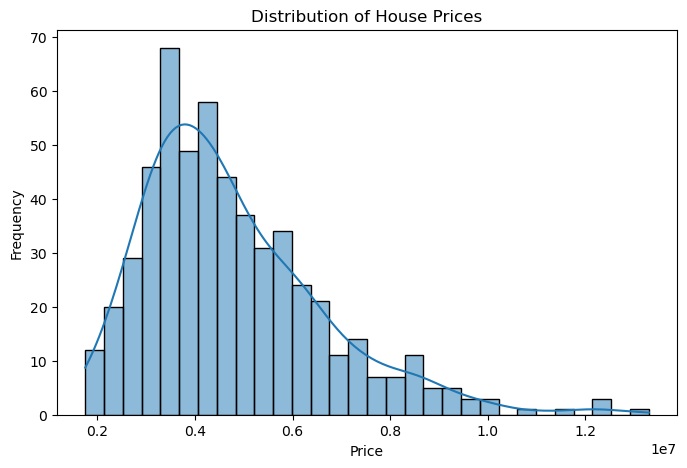

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(data["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig(
    "charts/house_price_distribution.png",
    bbox_inches="tight"
)

plt.show()

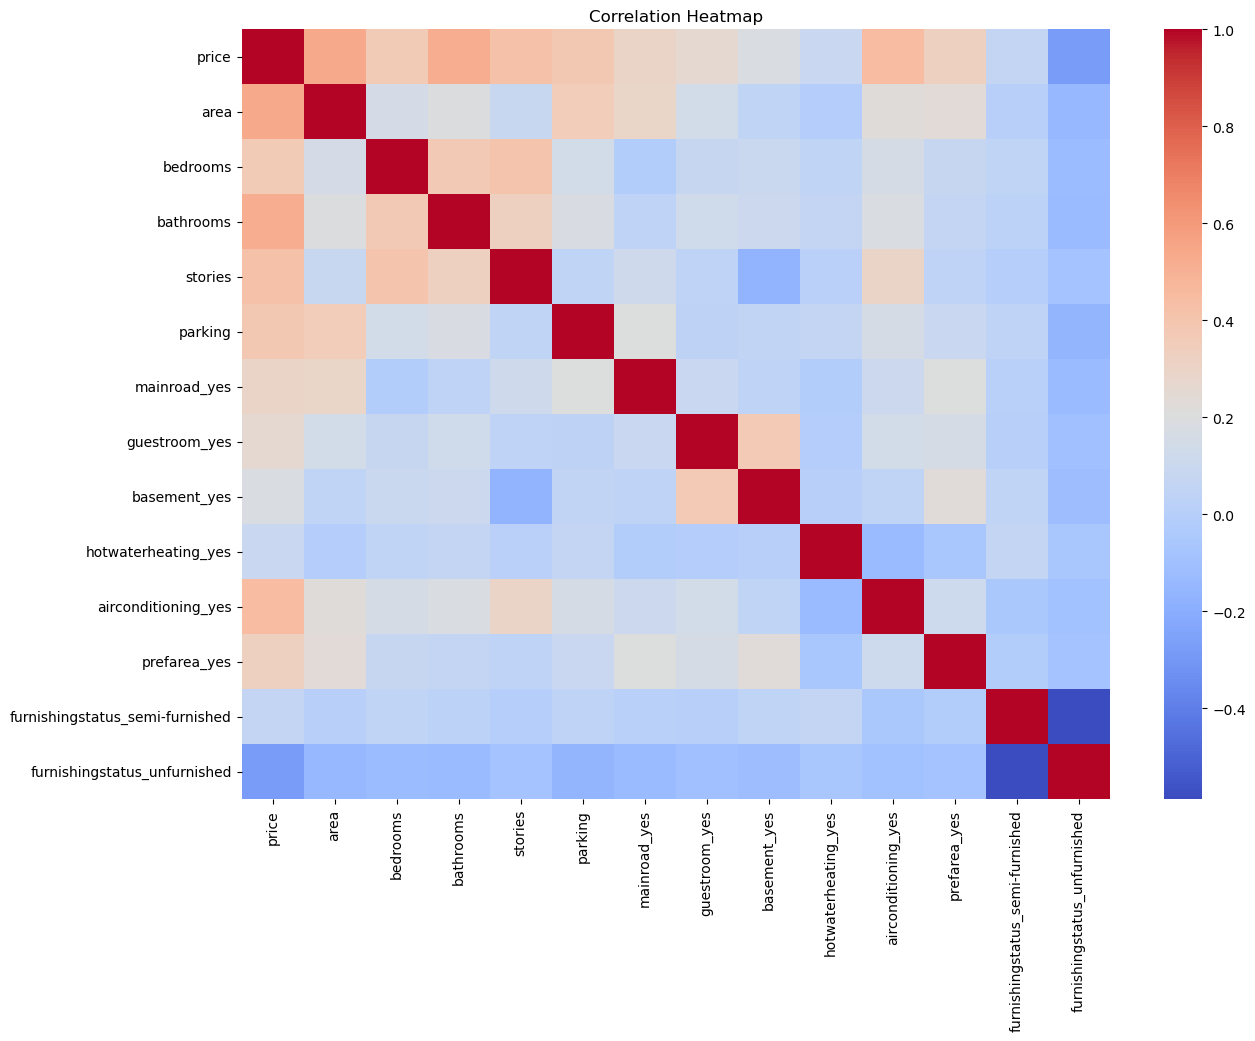

In [79]:
plt.figure(figsize=(14,10))

corr = df_encoded.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

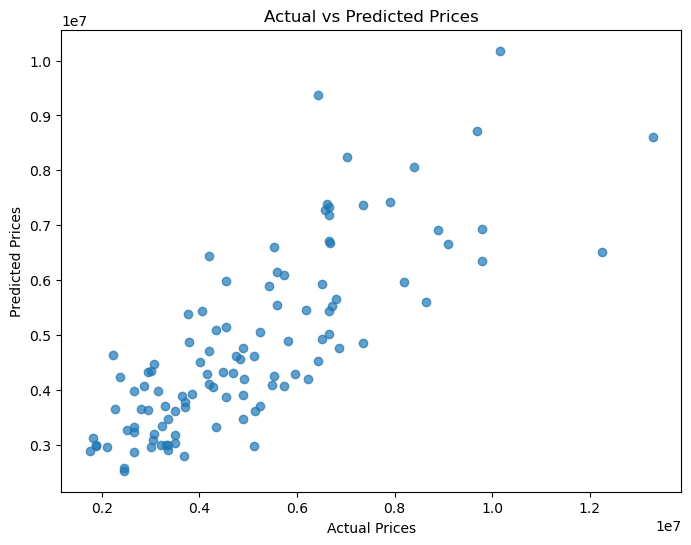

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,rf_predictions,alpha=0.7)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.savefig(
    "charts/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

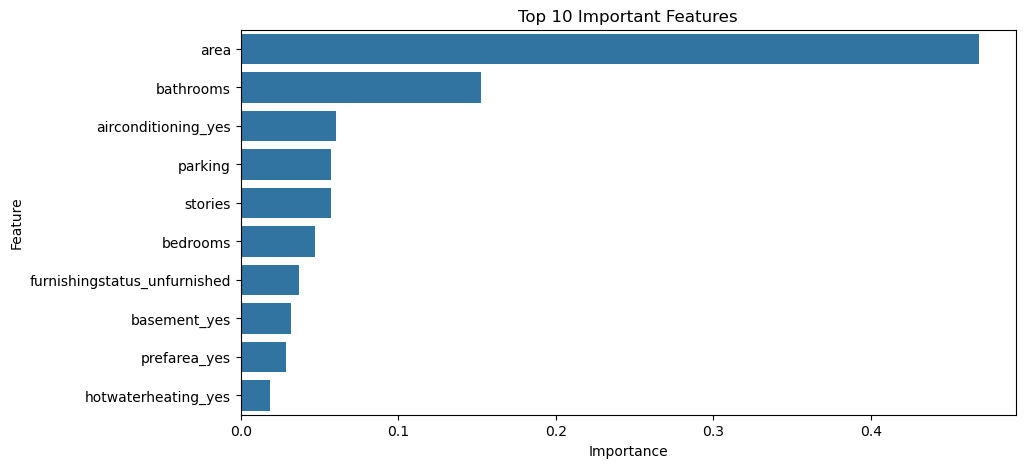

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(x='Importance',y='Feature',data=importance.head(10))

plt.title("Top 10 Important Features")

plt.show()

## Insights and Summary
The analysis showed that house area, number of bathrooms, number of stories, parking availability, and amenities such as air conditioning and preferred location were among the most influential factors affecting house prices. The best-performing model was Linear Regression, which achieved an R² score of 0.653, meaning it was able to explain approximately 65% of the variation in house prices and provide reasonably accurate predictions. One surprising observation was that certain amenities and location-related features had a significant impact on price, sometimes comparable to structural characteristics such as the number of bedrooms. Based on these findings, real estate businesses should focus on highlighting property size, location advantages, parking facilities, and premium amenities when pricing and marketing homes, as these factors contribute strongly to property value.